# Homework Assignment 4
## Regression and Classification models

### <p style="text-align: right;"> &#9989; Put your name here.</p>
### <p style="text-align: right;"> &#9989; Put your _GitHub username_ here.</p>

### Goal for this homework assignment
By now, you have learned a bit about regression models. In this assignment, you will practice:

* Using branches in Git
* Performing multiple linear regression
* Performing classification with logistic regression, perceptrons, and SVMs
* Using PCA for dimensionality reduction

**This assignment is due by 11:59 pm on Friday, April 24th.** It should be uploaded into the "Homework Assignments" submission folder for Homework 4.  Submission instructions can be found at the end of the notebook. **There are 70 standard points possible in this assignment. The distribution of points can be found in the section headers**.


---
## Part 1: Git Branch (6 points)

<img src="https://thumb.ac-illust.com/5d/5d177cfa2b1d4adf086d924032723df4_t.jpeg" alt='https://en.ac-illust.com/clip-art/22520113/school-anthropometry' width=250px align="right" style="margin-left: 15px">

For this assignment, you're going to add it to the `cmse202-s26-turnin` repository you created in class so that you can track your progress on the assignment and preserve the final version that you turn in. In order to do this you need to

**&#9989; Do the following**:

1. Navigate to your `cmse202-s26-turnin` **local** repository and create a new directory called `hw-04`

2. Move this notebook into that **new directory** in your repository, but **do not** add or commit it to your repository yet.

3. Create a **new branch** called `hw04_branch` 

4. "Check out" the new branch (so that you'll be working on that branch). 

5. Double check to make sure you are actually on that branch.

6. Once you're certain you're working on your new branch, add this notebook to your repository, then make a commit and push it to GitHub. You may need to use `git push origin hw04_branch` to push your new branch to GitHub.

Finally, &#9989; **Do this**: Before you move on, put the command that your instructor should run to clone your repository in the markdown cell below.

<font size=6 color="#009600">&#9998;</font> git clone https://github.com/arshwasnik/cmse202-s26-turnin/

**Important**: Double check you've added your Professor and your TA as collaborators to your "turnin" repository (you should have done this in the previous homework assignment).

**Also important**: Make sure that the version of this notebook that you are working on is the same one that you just added to your repository! If you are working on a different copy of the notebook, **none of your changes will be tracked**!

If everything went as intended, the file should now show up on your GitHub account in the "`cmse202-s26-turnin`" repository inside the `hw-04` directory that you just created within the new branch `hw04-branch`.

Periodically, **you'll be asked to commit your changes to the repository and push them to the remote GitHub location**. Of course, you can always commit your changes more often than that, if you wish.  It can be good to get into a habit of committing your changes any time you make a significant modification, or when you stop working on the project for a bit.


---
## Part 2: Loading and Summarizing an Anthropometric Dataset (9 points)
 <img src="https://www.egr.msu.edu/~aalessio/imgs/the-proportions-of-the-human-figure-leonardo-da-vinci.png"
     alt="da vinci human"
     align="right"  
     width="200" />  

<a href="https://en.wikipedia.org/wiki/Anthropometry">**Anthropometry**</a> is the scientific study of the measurements and proportions of the human body.  This field has a critical role in several industries including clothing design, ergonomics, healthcare, consumer safety, and architecture. 

For the majority of this homework, you'll be working with the The "anthrokids_subset.csv" file that contains 5 columns with the following contents: 

**[Age (years), Weight (kg), Height (cm), Head Circumference (cm), Waist Circumference (cm)].**  

These data are a subset of the data acquired in the 
<a href="http://mreed.umtri.umich.edu/mreed/downloads.html#child_anthro">Synder et al, 1975: ANTHROPOMETRY OF INFANTS,CHILDREN, AND YOUTHS TO AGE 18 FOR PRODUCT SAFETY DESIGN,</a> performed by the U.S. Consumer Product Safety Commission to design some of the original car seats for children. 

The dataset is available here:

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/anthrokids3_subset.csv`

&#9989; **Question 2.1 (1 points)**: To get started, **download the `anthrokids3_subset.csv` file and place it in the same directory as your notebook**.

``` bash
curl -O https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/anthrokids3_subset.csv
```

&#9989;  **Question 2.2 (2 points)**: Next, load the data into a Pandas DataFrame and display the first and last 5 rows. 

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

anth_df = pd.read_csv("anthrokids3_subset.csv")

anth_df.head()

anth_df.tail()

,age,weight,height,waist_circum,head_circum
1772,4.704,20.1,108.6,57.4,52.8
1773,4.131,17.8,100.8,50.6,49.7
1774,5.120,21.7,114.9,53.1,51.2
1775,5.342,20.7,112.1,52.9,51.9
1776,5.495,18.1,110.8,46.8,48.9


&#9989;  **Question 2.3 (2 points)**: First, convert all of these variables from metric to imperial units (i.e. weight from kg to pounds, height from cm to feet, and head circumference and waist circumference from cm to inches). Display the mean and standard deviation of each variable after converting to imperial units.  If you created new columns for the imperial units, we suggest that you remove the old columns that have the metric units.




In [7]:
anth_df["weight"] = anth_df["weight"] * 2.204
anth_df["height"] = anth_df["height"] / 30.48
anth_df["waist_circum"] = anth_df["waist_circum"] / 2.54
anth_df["head_circum"] = anth_df["head_circum"] / 2.54

anth_df.describe().loc[["mean","std"]]

,age,weight,height,waist_circum,head_circum
mean,10.579407,82.952631,4.583215,24.421546,20.804882
std,4.201508,38.347446,0.785338,4.289688,1.013657


&#9989;  **Question 2.4 (4 points)**: For additional exploration of this data, make three scatter plots (side-by-side) that display the relationship between weight and age, and then height and age, and then waist circumference and age. You can use any plotting library you like for this task.  This should display weight (the dependent variable) as a function of age (the independent variable on the x-axis) and height (the dependent variable) as a function of age (the independent variable) and waist circumference (the dependent variable) as a function of age (the independent variable).  Label all of your axes.






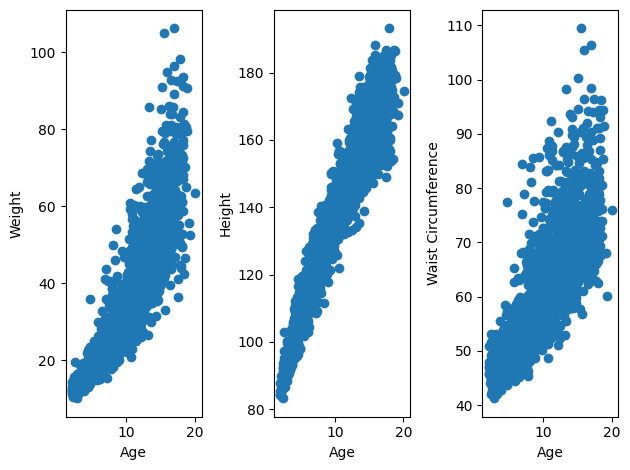

In [13]:
fig, axes = plt.subplots(1, 3)

axes[0].scatter(anth_df["age"], anth_df["weight"])
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Weight")

axes[1].scatter(anth_df["age"], anth_df["height"])
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Height")

axes[2].scatter(anth_df["age"], anth_df["waist_circum"])
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Waist Circumference")

plt.tight_layout()
plt.show()

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 2 complete", and push the changes to GitHub.



---
 <img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/images/helmet-logo-image.png"
     alt="perplexity pro,https://www.perplexity.ai,''Make a logo for a fictional company called Helmets 'R Us, Inc'', 4/1/2026"
     width="500"/>  

<span style="color: grey;">Perplexity pro,https://www.perplexity.ai,''Make a logo for a fictional company called Helmets 'R Us, Inc'', Accessed 4/1/2026</span>
## Part 3: Multivariable Linear Regression (9 points)


For this homework, let's assume that we work for a company that makes helmets for children (Helmet's R Us, Inc.).  We want to be able to predict good helmet sizes for children based on their age, weight, height, and waist circumference.  We have the data from the Synder et al. study to help us with this task.

In this part, we will try to estimate head circumference (which is a critical measurement for helmet size) using the other measurements in the dataset.  

&#9989;  **Question 3.1 (3 points)**: Using the `OLS` method in `statsmodels`, perform a linear regression to predict head circumference from the other variables and **display the results summary**. Make sure `OLS` fits a general line $y = ax+b$ to the data instead of a line through the origin $y = ax$. 

The input variables that you have access to are age, weight, height, and waist circumference. 



In [ ]:
# Put your code here

&#9989;  **Question 3.2 (4 points)**: Answer the following questions: 

1. What was the equation of the best fit linear relationship between the input variables and the target variable, head circumference? (2 pts)

2. Which input variable is least useful for detecting the target variable? What tells you this? (1 pts)

3. As age increases, how does the head circumference change? Describe a reason why this behavior occurs?  (1 pts)


<font size=+3>&#9998;</font> Put your 3 answers here:

&#9989;  **Question 3.3 (2 points)**: Based on this model, what is the head circumference of a child who is 5 years old, weighs 40 pounds, is 3.7 feet tall, and has a waist circumference of 21 inches? Show your work.

In [ ]:
# Put your code here or your manual calculations here 

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 3 complete", and push the changes to GitHub.

---

## Part 4: Logistic Regression 

Helmet's R Us, Inc. has made the decision to only make two sizes of helmets: Small (for infants) and Large (for older children). 

We will use classification techniques to determine which children should get the small helmets and which should get the large helmets. We will assume that parents and guardians will only have access to a child's age, weight, height when they are trying to decide which helmet size to buy.

&#9989;  **Question 4.1 (2 points)**: Binarize the head circumference variable to create a new dataframe column called `helmet_size` that has two values: "Small" for head circumferences less than 20.5 inches and "Large" for head circumferences greater than or equal to 20.5 inches. Display the first 10 rows of the new `helmet_size` column and the first 10 rows of the original `head_circumference` column to verify that you created the new variable correctly.

In [ ]:
# Put your code here

We want to prepare our data for the following classification models, with the understanding that you will be trying to predict the `helmet_size` variable using only the age, weight (in lbs), and height (in feet) variables.

&#9989;  **Question 4.2 (2 points)**: Create a new dataframe variable that has just the age, weight, and height variables (inputs) as the features and the `helmet_size` variable as the labels (output). Display the first 5 rows of the features and labels to verify that you created these variables correctly.

In [ ]:
# put your code here

&#9989;  **Question 4.3 (3 points)**: To gain some intuition of the relationship between the features and the labels, make three boxplots that display the distribution of age, weight, and height for each helmet size. You can use any plotting library you like for this task.  This should display the distribution of age, weight, and height for each helmet size. (boxplots of age on the y-axis and helmet size on the x-axis, boxplots of weight on the y-axis and helmet size on the x-axis, and boxplots of height on the y-axis and helmet size on the x-axis).  Label all of your axes.

In [ ]:
# Put your code here

&#9989;  **Question 4.4 (1 points)**: Now that you've visualized the data some, Do you think this data is linearly separable? Why or why not?

<font size=+3>&#9998;</font> Put your answers here:

&#9989;  **Question 4.5 (2 points)**: Finally, before we start creating our models, let's first split our data into training and testing datasets. Make the training set have 75\% of the data and the testing set have 25\% of the data. Set the random seed to 42 so that your results are reproducible. 

In [ ]:
# Put your code here

&#9989;  **Question 4.6 (4 points)**: Now, train a logistic regression model to predict helmet size from age, weight, and height. Perform the training on the training set.  Display a summary of the model (to show the coefficients for each feature).  You can use methods from `statsmodels` or `sklearn` to perform logistic regression. 

In [ ]:
# Put your code here

&#9989;  **Question 4.7 (2 points)**: Evaluate the performance on the training and testing set.  Display the accuracy of the logistic regression model when applied to both the training and testing sets.

**Note:** Accuracy should be better than 75% on the test set.  If you are not getting better than 75% accuracy on the test set, try to troubleshoot your code and see if you can find any errors. If you can't find any errors, then just report the accuracy that you got and move on to the next question.

In [ ]:
# Put your code here

&#9989;  **Question 4.8 (2 points)**: In the markdown cell below, write the equation of the logistic regression model that you trained in Question 4.6.  Make sure to include the coefficients for each feature and the intercept, and include the use of the logistic function.  Also, explain how you would use this equation to predict helmet size for a new child given their age, weight, and height.

<font size=+3>&#9998;</font> Put your answers here:

&#9989;  **Question 4.9 (1 points)**: Based on this model, what is the helmet size of a child who is 5 years old, weighs 40 pounds, is 3.7 feet tall? Show your work or include code below to make the prediction using your model.

In [ ]:
# Put your code here

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 4 complete", and push the changes to GitHub.

---

## Part 5: Classification with a Perceptron (14 points)

In this part, we'll use the perceptron class built in Day 18 and Day 19 assignments to classify whether a child should get a Small or Large helmet.

&#9989;  **Question 5.1 (3 points)**: Convert your target labels in both your training and testing sets to binary values (-1 for "Small" and 1 for "Large"). This is needed for training a perceptron model, which outputs binary predictions of -1 or 1.

In [ ]:
# Put your code here


#### Binary perceptron classifier

&#9989;  **Question 5.2 (5 points)**:Copy your perceptron class to the cell below. (the one developed in Day 18 and Day 19 assignments).

* DO NOT use the one from statsmodel. We want to test the perceptron you built.
* Note that your predict method should output `+1` or `-1` for positive or negative values, respectively.


In [ ]:
# Put your code here


&#9989;  **Question 5.3 (3 points)**: Train an instance of your perceptron class on the training data.  Display the final weights and bias after training.


In [ ]:
# Put your code here

&#9989;  **Question 5.4 (3 points)**: What is the accuracy of this model for classifying helmet size on the training and testing sets?  Does this perform better or worse than the logistic regression model you trained in Part 4?  

In [ ]:
# Put your code here

&#9989;  **Question 5.5 (2 points)**: In the markdown cell below, write the equation of the decision function of perceptron model that you trained in Question 5.3.  Make sure to include the coefficients for each feature and the intercept, and include the use of the activation function.  Also, explain how you would use this equation to predict helmet size for a new child given their age, weight, and height.

<font size=+3>&#9998;</font> Put your answers here:

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 5 complete", and push the changes to GitHub.

---

## Part 6: Support Vector Machines (SVMs) and PCA

In this part, we are going to train a support vector machine (SVM) classifier on the same data and compare its performance to the logistic regression and perceptron models that we trained in Parts 4 and 5. We will also use PCA to visualize the data in two dimensions.

&#9989;  **Question 6.1 (4 points)**: Train a support vector machine (SVM) classifier to predict helmet size from age, weight, and height. Perform the training on the training set. 

Some notes:
- You should use methods from `sklearn` to perform SVM classification.
- Use the RBF kernel for the SVM and set the regularization parameter `C` to 1.0.

In [ ]:
# Put your code here

&#9989;  **Question 6.2 (3 points)**: What is the accuracy of this model for classifying helmet size on the training and testing sets?  Does this perform better or worse than the logistic regression and perceptron models you trained in Parts 4 and 5?

In [ ]:
# Put your code here

&#9989;  **Question 6.3 (4 points)**: Use Principal Component Analysis (PCA) to reduce the dimensionality of the feature space from 3 dimensions (age, weight, height) to 2 dimensions. Then, create a scatter plot of the data points in this 2D PCA space, coloring the points according to their helmet size (Small or Large). Label your axes and include a legend.

**Note:** The PCA should be fit on the training data to ensure that the PCA transformation is based only on the training data.  The plot should include only the PCA transformation of the test data points.  (Basically, fit on the training data, but plot the test data in the PCA space).

In [ ]:
# Put your code here

&#9989;  **Question 6.4 (3 points)**: Using **only one** of the principal components from the PCA performed above, how well can you classify helmet size using a simple threshold on that principal component?  In other words, find a threshold value for the first principal component that best separates the Small and Large helmet sizes in the training data (HINT: You can find this threshold manually or with one of the classification methods we've discussed in class). Then, evaluate the accuracy of this simple classifier on the testing sets.   How does this accuracy compare to the logistic regression, perceptron, and SVM models you trained in previous questions?


In [ ]:
# Put your code here

&#9989;  **Question 6.5 (EXTRA CREDIT, 3 points)**: Repeat the scatter plot from question **6.3** showing Principal Component 1 on the x-axis and Principal Component 2 on the y-axis, but this time, add the decision boundary that you found from question **6.4** to the plot.  This should be a vertical line if you used the Principal Component from x-axis or a horizontal line if you used the Principal Component from y-axis.  Label your axes and include a legend.


In [ ]:
# Put your code here

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 6 complete", and push the changes to GitHub.



---
## Part 1. Continued

Now that you've finished your new "development" on your 202 turn-in repo, you can merge your work back into your `main` branch.

**&#9989; Do the following**:

7. Switch back to your `main` branch. 
8. Merge your `hw04_branch` with your `main` branch. 
9. Finally, push the changes to GitHub.

---
## Congratulations, you're done!

<img src="https://target.scene7.com/is/image/Target/GUEST_7dcf3394-4598-4bb8-886c-7f174b8f1a9b?wid=384&qlt=80" alt='Unicorn Helment @ Target.com' width=200px>

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" folder, find the dropbox link for Homework 4, and upload it there.

&#169; Copyright 2026,  Department of Computational Mathematics, Science and Engineering at Michigan State University